In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [26]:
import os

# Create folder named "EPS"
os.makedirs("EPS", exist_ok=True)

print("EPS folder created successfully!")

EPS folder created successfully!


In [2]:
data = pd.read_csv("data_banknote_authentication.txt",
                   header=None)

data.columns = [
    "Variance",
    "Skewness",
    "Curtosis",
    "Entropy",
    "Target Class"
]

data.head()

print("First Five Samples")

data.head()

First Five Samples


,Variance,Skewness,Curtosis,Entropy,Target Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [3]:
print("Dataset Shape")

print(data.shape)

Dataset Shape
(1372, 5)


In [4]:
print("Missing Values")

print(data.isnull().sum())

Missing Values
Variance        0
Skewness        0
Curtosis        0
Entropy         0
Target Class    0
dtype: int64


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Variance      1372 non-null   float64
 1   Skewness      1372 non-null   float64
 2   Curtosis      1372 non-null   float64
 3   Entropy       1372 non-null   float64
 4   Target Class  1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [6]:
data.describe()

,Variance,Skewness,Curtosis,Entropy,Target Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


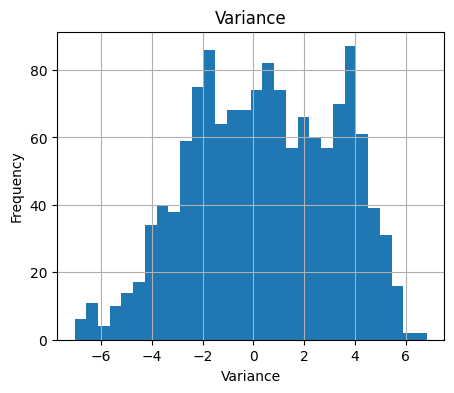

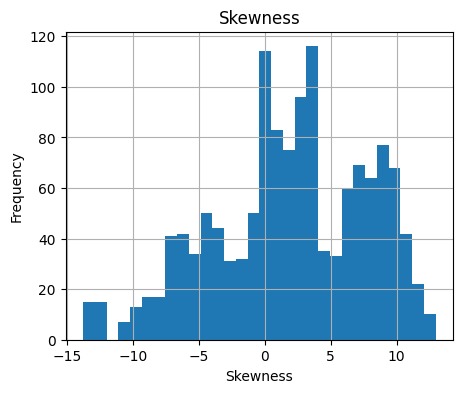

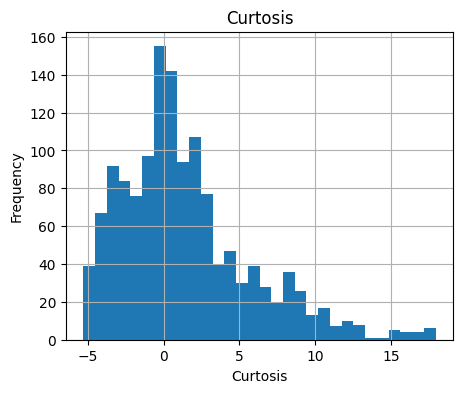

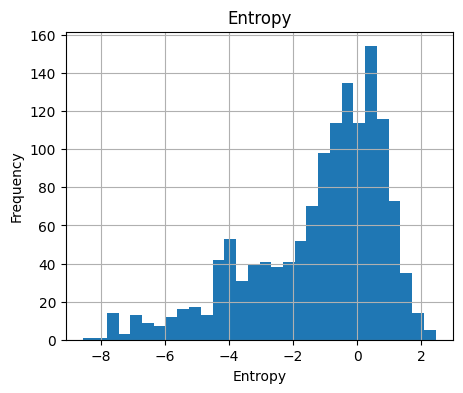

In [30]:
features = data.columns[:-1]

for feature in features:

    plt.figure(figsize=(5,4))

    plt.hist(data[feature], bins=30)

    plt.title(feature)

    plt.xlabel(feature)

    plt.ylabel("Frequency")

    plt.grid(True)

    plt.savefig(
        f"EPS/Histogram_{feature}.eps",
        format="eps",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

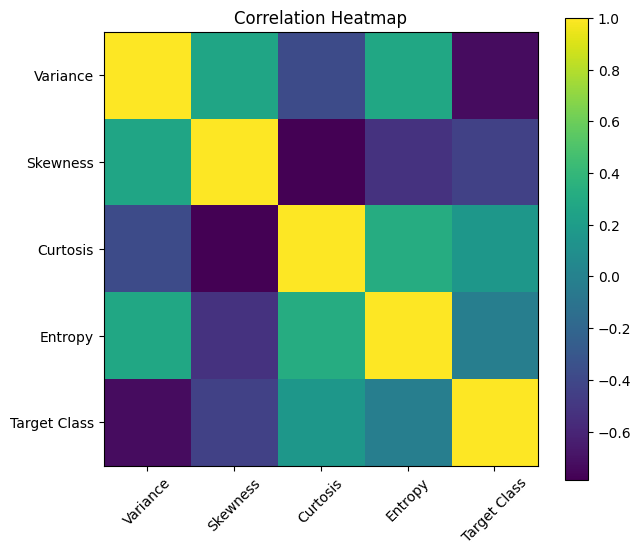

In [31]:
corr = data.corr()

plt.figure(figsize=(7,6))

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.savefig(
    "EPS/Correlation_Heatmap.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

plt.close()

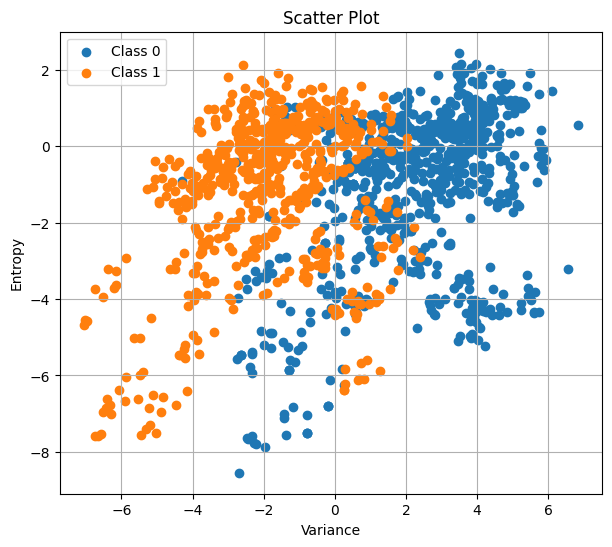

In [32]:
plt.figure(figsize=(7,6))

for cls in data["Target Class"].unique():

    subset = data[data["Target Class"] == cls]

    plt.scatter(
        subset["Variance"],
        subset["Entropy"],
        label=f"Class {cls}"
    )

plt.xlabel("Variance")

plt.ylabel("Entropy")

plt.title("Scatter Plot")

plt.legend()

plt.grid(True)

plt.savefig(
    "EPS/Scatter_Plot.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

plt.close()

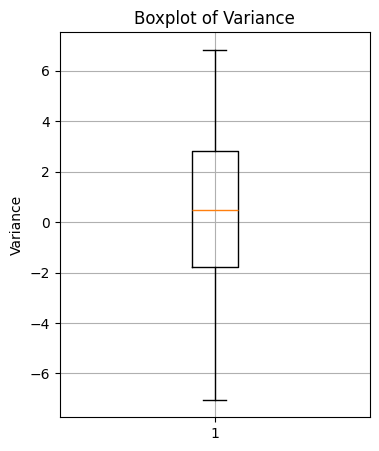

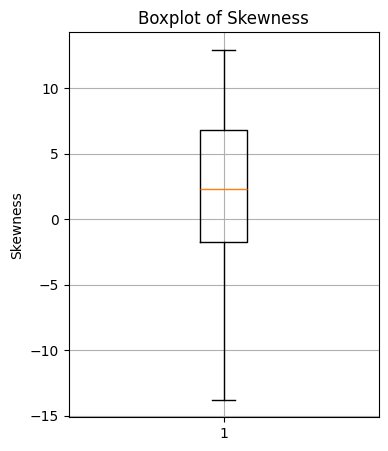

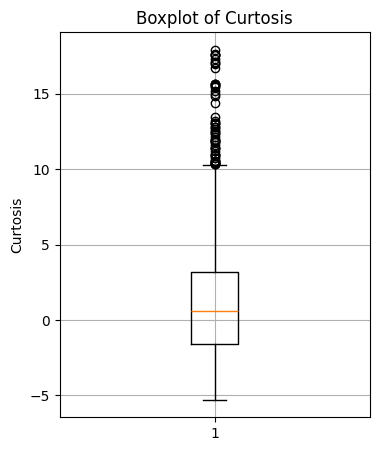

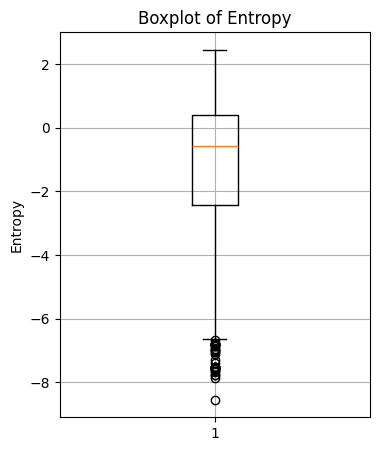

In [33]:
features = data.columns[:-1]

for feature in features:

    plt.figure(figsize=(4,5))

    plt.boxplot(data[feature])

    plt.title(f"Boxplot of {feature}")

    plt.ylabel(feature)

    plt.grid(True)

    plt.savefig(
        f"EPS/Boxplot_{feature}.eps",
        format="eps",
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

In [11]:
X = data.iloc[:, :-1]

y = data.iloc[:, -1]

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[0.76900389 0.83964273 0.10678269 0.73662766]
 [0.83565902 0.82098209 0.12180412 0.64432563]
 [0.78662859 0.41664827 0.31060805 0.78695091]
 [0.75710505 0.87169921 0.05492063 0.45043964]
 [0.53157807 0.34866247 0.42466237 0.6873619 ]]


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)

print(X_test.shape)

(1097, 4)
(275, 4)


In [13]:
class Perceptron:

    def __init__(self, learning_rate=0.01, epochs=20):

        self.lr = learning_rate

        self.epochs = epochs

        self.weights = None

        self.bias = None

        self.errors = []

        self.weight_history = []

        self.bias_history = []

    def step(self, z):

        if z >= 0:

            return 1

        return 0

    def fit(self, X, y):

        samples, features = X.shape

        self.weights = np.zeros(features)

        self.bias = 0

        for epoch in range(self.epochs):

            error_count = 0

            for i in range(samples):

                z = np.dot(X[i], self.weights) + self.bias

                prediction = self.step(z)

                update = self.lr * (y.iloc[i] - prediction)

                self.weights += update * X[i]

                self.bias += update

                if update != 0:

                    error_count += 1

            self.errors.append(error_count)

            self.weight_history.append(self.weights.copy())

            self.bias_history.append(self.bias)

            print("Epoch:", epoch+1)

            print("Errors:", error_count)

            print("Weights:", self.weights)

            print("Bias:", self.bias)

            print("---------------------------")

    def predict(self, X):

        predictions = []

        for sample in X:

            z = np.dot(sample, self.weights) + self.bias

            predictions.append(self.step(z))

        return np.array(predictions)

In [14]:
model = Perceptron(
    learning_rate=0.01,
    epochs=20
)

model.fit(X_train, y_train)

Epoch: 1
Errors: 166
Weights: [-0.06827408 -0.03866853 -0.05319097  0.01529354]
Bias: 0.08
---------------------------
Epoch: 2
Errors: 88
Weights: [-0.0831161  -0.06146315 -0.07687838  0.01162422]
Bias: 0.09999999999999999
---------------------------
Epoch: 3
Errors: 57
Weights: [-0.08731574 -0.0656554  -0.09593051  0.01506002]
Bias: 0.10999999999999999
---------------------------
Epoch: 4
Errors: 51
Weights: [-0.09538568 -0.07974311 -0.09285397  0.01017015]
Bias: 0.11999999999999998
---------------------------
Epoch: 5
Errors: 47
Weights: [-0.09778344 -0.0856403  -0.1002551   0.00578113]
Bias: 0.12999999999999998
---------------------------
Epoch: 6
Errors: 45
Weights: [-0.1058116  -0.08861835 -0.1014938   0.00433029]
Bias: 0.13999999999999999
---------------------------
Epoch: 7
Errors: 48
Weights: [-0.1116004  -0.09912635 -0.10830018  0.00909124]
Bias: 0.13999999999999999
---------------------------
Epoch: 8
Errors: 32
Weights: [-0.11796496 -0.1012441  -0.11616     0.00999082]
Bias

In [15]:
predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

precision = precision_score(y_test, predictions)

recall = recall_score(y_test, predictions)

f1 = f1_score(y_test, predictions)

print("Accuracy :", accuracy)

print("Precision :", precision)

print("Recall :", recall)

print("F1 Score :", f1)

Accuracy : 0.9745454545454545
Precision : 0.9477611940298507
Recall : 1.0
F1 Score : 0.9731800766283525


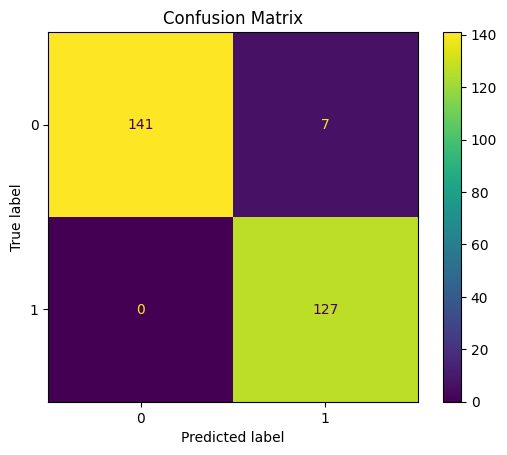

In [34]:
cm = confusion_matrix(y_test, predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix")

plt.savefig(
    "EPS/Confusion_Matrix.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

plt.close()

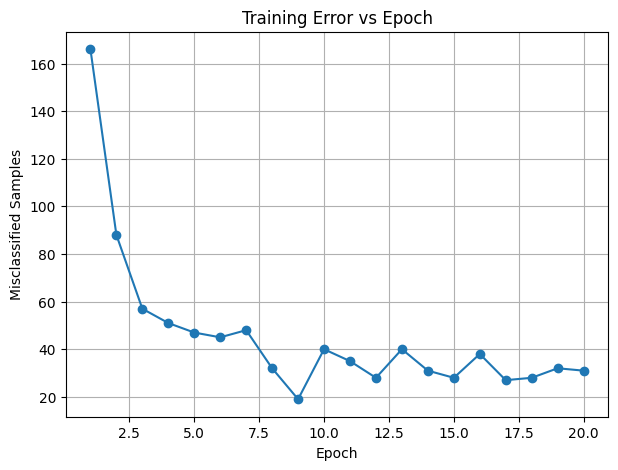

In [35]:
plt.figure(figsize=(7,5))

epochs = range(1, len(model.errors) + 1)

plt.plot(
    epochs,
    model.errors,
    marker='o'
)

plt.xlabel("Epoch")

plt.ylabel("Misclassified Samples")

plt.title("Training Error vs Epoch")

plt.grid(True)

plt.savefig(
    "EPS/Training_Error_vs_Epoch.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

plt.close()

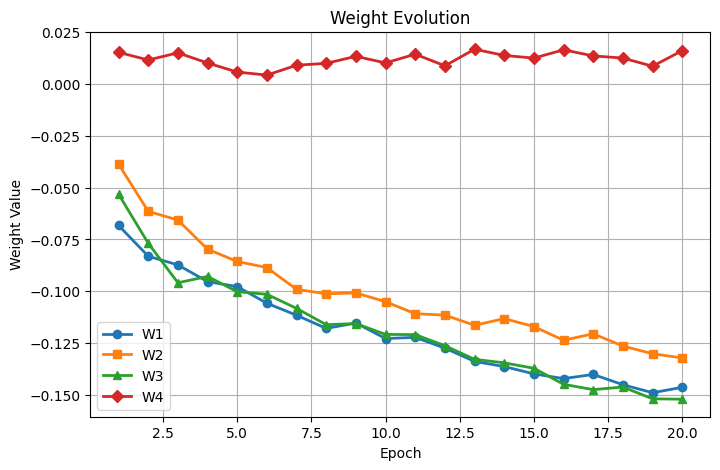

In [36]:
weights = np.array(model.weight_history)

plt.figure(figsize=(8,5))

epochs = range(1, len(weights) + 1)

markers = ['o', 's', '^', 'D']

for i in range(weights.shape[1]):

    plt.plot(
        epochs,
        weights[:, i],
        marker=markers[i],
        linewidth=2,
        label=f"W{i+1}"
    )

plt.xlabel("Epoch")

plt.ylabel("Weight Value")

plt.title("Weight Evolution")

plt.legend()

plt.grid(True)

plt.savefig(
    "EPS/Weight_Evolution.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

plt.close()

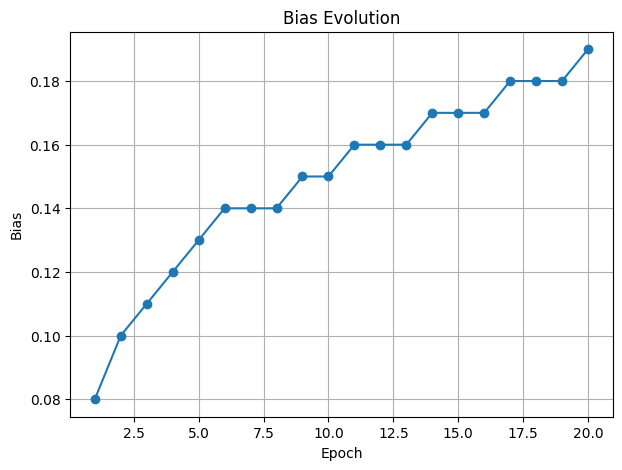

In [37]:
plt.figure(figsize=(7,5))

epochs = range(1, len(model.bias_history) + 1)

plt.plot(
    epochs,
    model.bias_history,
    marker='o'
)

plt.xlabel("Epoch")

plt.ylabel("Bias")

plt.title("Bias Evolution")

plt.grid(True)

plt.savefig(
    "EPS/Bias_Evolution.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

plt.close()

Epoch: 1
Errors: 166
Weights: [-0.00682741 -0.00386685 -0.0053191   0.00152935]
Bias: 0.008
---------------------------
Epoch: 2
Errors: 88
Weights: [-0.00831161 -0.00614632 -0.00768784  0.00116242]
Bias: 0.010000000000000002
---------------------------
Epoch: 3
Errors: 57
Weights: [-0.00873157 -0.00656554 -0.00959305  0.001506  ]
Bias: 0.011000000000000003
---------------------------
Epoch: 4
Errors: 51
Weights: [-0.00953857 -0.00797431 -0.0092854   0.00101702]
Bias: 0.012000000000000004
---------------------------
Epoch: 5
Errors: 47
Weights: [-0.00977834 -0.00856403 -0.01002551  0.00057811]
Bias: 0.013000000000000005
---------------------------
Epoch: 6
Errors: 45
Weights: [-0.01058116 -0.00886184 -0.01014938  0.00043303]
Bias: 0.014000000000000005
---------------------------
Epoch: 7
Errors: 48
Weights: [-0.01116004 -0.00991264 -0.01083002  0.00090912]
Bias: 0.014000000000000005
---------------------------
Epoch: 8
Errors: 32
Weights: [-0.0117965  -0.01012441 -0.011616    0.0009990

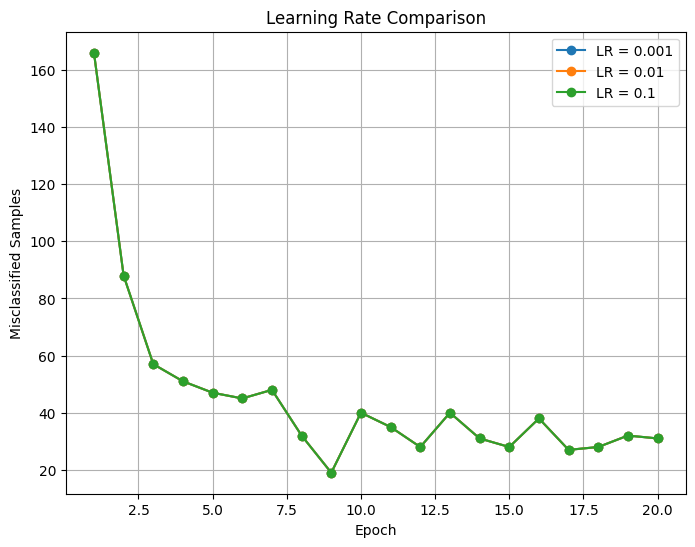

In [38]:
rates = [0.001, 0.01, 0.1]

plt.figure(figsize=(8,6))

for rate in rates:

    p = Perceptron(
        learning_rate=rate,
        epochs=20
    )

    p.fit(X_train, y_train)

    plt.plot(
        range(1, 21),
        p.errors,
        marker='o',
        label=f"LR = {rate}"
    )

plt.xlabel("Epoch")

plt.ylabel("Misclassified Samples")

plt.title("Learning Rate Comparison")

plt.legend()

plt.grid(True)

plt.savefig(
    "EPS/Learning_Rate_Comparison.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

plt.close()

In [22]:
summary = pd.DataFrame({
    "Metric":[
        "Dataset Size",
        "Train Size",
        "Test Size",
        "Learning Rate",
        "Epochs",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Value":[
        len(data),
        len(X_train),
        len(X_test),
        model.lr,
        model.epochs,
        accuracy,
        precision,
        recall,
        f1
    ]
})

summary

,Metric,Value
0,Dataset Size,1372.000000
1,Train Size,1097.000000
2,Test Size,275.000000
3,Learning Rate,0.010000
4,Epochs,20.000000
5,Accuracy,0.974545
6,Precision,0.947761
7,Recall,1.000000
8,F1 Score,0.973180


In [23]:
epoch_table = pd.DataFrame({
    "Epoch": range(1, model.epochs + 1),
    "Errors": model.errors,
    "Weight1": [w[0] for w in model.weight_history],
    "Weight2": [w[1] for w in model.weight_history],
    "Weight3": [w[2] for w in model.weight_history],
    "Weight4": [w[3] for w in model.weight_history],
    "Bias": model.bias_history
})

epoch_table

,Epoch,Errors,Weight1,Weight2,Weight3,Weight4,Bias
0,1,166,-0.068274,-0.038669,-0.053191,0.015294,0.08
1,2,88,-0.083116,-0.061463,-0.076878,0.011624,0.10
2,3,57,-0.087316,-0.065655,-0.095931,0.015060,0.11
3,4,51,-0.095386,-0.079743,-0.092854,0.010170,0.12
4,5,47,-0.097783,-0.085640,-0.100255,0.005781,0.13
5,6,45,-0.105812,-0.088618,-0.101494,0.004330,0.14
6,7,48,-0.111600,-0.099126,-0.108300,0.009091,0.14
7,8,32,-0.117965,-0.101244,-0.116160,0.009991,0.14
8,9,19,-0.115347,-0.100825,-0.115625,0.013377,0.15
9,10,40,-0.122859,-0.105055,-0.120860,0.010205,0.15


In [39]:
import shutil

shutil.make_archive("EPS", "zip", "EPS")

print("EPS.zip created successfully!")

from google.colab import files

files.download("EPS.zip")

EPS.zip created successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>